In [1]:
import json
from torch.utils.data.distributed import DistributedSampler
from core.dataset import TrainDataset
from core.prefetch_dataloader import PrefetchDataLoader, CPUPrefetcher
import torch
import os

import matplotlib.pyplot as plt


os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

config = json.load(open("./configs/train_depthcomp.json"))
config["world_size"] = torch.cuda.device_count()
# config["init_method"] = f"tcp://{get_master_ip()}:{args.port}"
config["distributed"] = True if config["world_size"] > 1 else False

train_dataset = TrainDataset(config["train_data_loader"])
train_sampler = None
train_args = config["trainer"]
if config["distributed"]:
    train_sampler = DistributedSampler(
        train_dataset,
        num_replicas=config["world_size"],
        rank=config["global_rank"],
    )

dataloader_args = dict(
    dataset=train_dataset,
    batch_size=train_args["batch_size"] // config["world_size"],
    shuffle=(train_sampler is None),
    num_workers=train_args["num_workers"],
    sampler=train_sampler,
    drop_last=True,
)

train_loader = PrefetchDataLoader(
    train_args["num_prefetch_queue"], **dataloader_args
)
prefetcher = CPUPrefetcher(train_loader)

In [2]:
frame_tensors, mask_tensors, depth_tensors, flows_f, flows_b, video_name = next(iter(train_loader))


<Figure size 640x480 with 0 Axes>

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


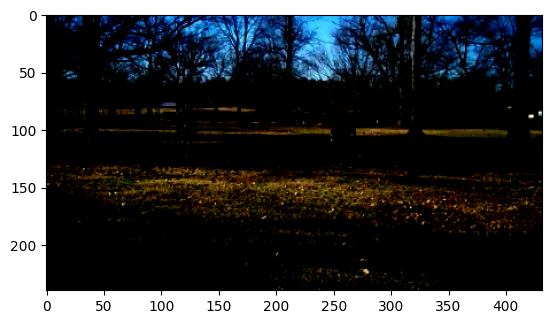

In [7]:
plt.imshow(frame_tensors[0][3].permute(1,2,0).numpy())

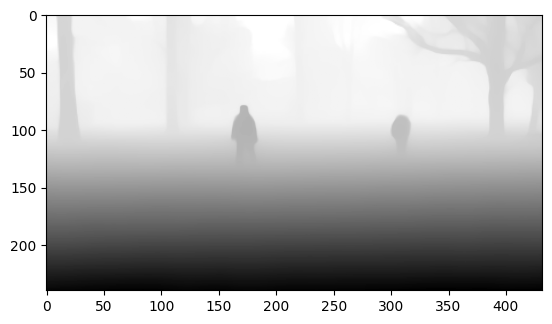

In [6]:
plt.imshow(depth_tensors[0][3].squeeze().numpy(), cmap="gray")